In [1]:
import dotenv 
from pathlib import Path
from IPython.display import HTML

from text2graph.eval_dataset.data import squadquestions_from_json
from text2graph.eval_dataset.schema import SQuADStratPipelineQuestion


dotenv.load_dotenv()

True

# load handpicked squad questions

Loaded 106 lines from ../data/20240806_combined_test_triplets.json
Preprocessed to 109 lines



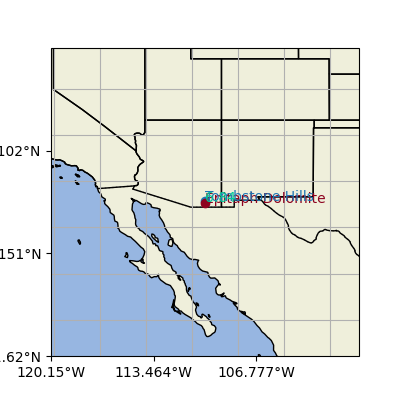

In [2]:
squad_questions_json_path = Path("../data/20240806_combined_test_triplets.json")
squad_questions = squadquestions_from_json(squad_questions_json_path=squad_questions_json_path)
HTML(squad_questions[0].html_format())

In [9]:
from text2graph.eval_dataset.data import label_impossible

labelled_questions = label_impossible(questions=squad_questions)

Impossible: 36, Possible: 73


# query location_stratname API with hand picked squad question context

In [11]:
from text2graph.eval_dataset.assessment import query_text_to_graph_api

response = query_text_to_graph_api(labelled_questions[90].context)


In [15]:
response

{'triplets': [{'subject': {'name': 'Candelaria mine',
    'lat': 38.1504843,
    'lon': -118.083169,
    'provenance': {'id': '7b5d0c25-f078-462f-97c2-cb7a7cc092f7',
     'source_name': 'GeocodeAPI',
     'source_url': 'https://geocode.maps.co/search?&q=Candelaria mine',
     'source_version': None,
     'requested': '2024-08-16T16:43:48.346344',
     'additional_values': {},
     'previous': {'id': 'c5c1c60f-d079-4aca-839f-bbbdd67f2c63',
      'source_name': 'OpenSourceModel',
      'source_url': None,
      'source_version': 'mixtral',
      'requested': '2024-06-11T18:15:34.698799Z',
      'additional_values': {'temperature': 0.0, 'prompt': 'v3', 'doc_ids': []},
      'previous': None}}},
   'predicate': 'is divided',
   'object': {'strat_name': 'Candelaria',
    'strat_name_long': 'Candelaria Formation',
    'rank': 'Fm',
    'strat_name_id': 297,
    'concept_id': 12471,
    'bed': '',
    'bed_id': 0,
    'mbr': '',
    'mbr_id': 0,
    'fm': 'Candelaria',
    'fm_id': 297,
    '

# extract subject, predicate, object from response

In [22]:
from text2graph.eval_dataset.assessment import response_subject_predicate_objects

subject_predicate_object_strs = response_subject_predicate_objects(response)
subject_predicate_object_strs


[{'subject': 'Prince Rupert-Skeena area',
  'predicate': 'underlain by',
  'object': 'plutonic and metamorphic rocks of the Coast Plutonic Complex'},
 {'subject': 'area between the Skeena River and Douglas Channel',
  'predicate': 'contains',
  'object': 'Scotia-Quaal metamorphic complex'},
 {'subject': 'Scotia-Quaal metamorphic complex',
  'predicate': 'consists of',
  'object': 'metavolcanic and metasedimentary rocks'}]

# check responses for exact match

In [14]:
from text2graph.eval_dataset.assessment import question_best_exact_match

question_best_exact_match(labelled_questions[90], subject_predicate_object_strs)

0

# get best response f1

In [31]:
from text2graph.eval_dataset.assessment import question_best_mean_f1

question_best_mean_f1(labelled_questions[90], subject_predicate_object_strs)

0.0

# run on subset of questions

In [33]:
exact_matches = {}
mean_f1s = {}
responses = {}
for i, q in enumerate(labelled_questions[::10]):
    try:
        response = query_text_to_graph_api(q.context)
        responses[i] = response
        subject_predicate_object_strs = response_subject_predicate_objects(response)
        exact_matches[i] = question_best_exact_match(q, subject_predicate_object_strs)
        mean_f1s[i] = question_best_mean_f1(q, subject_predicate_object_strs)
    except Exception as e:
        print(f"Error on question{i}: {e}")
        

print(f"Exact Matches: {sum(exact_matches.values())/len(exact_matches.values())}")
print(f"Mean F1: {sum(mean_f1s.values())/len(mean_f1s.values())}")


Error on question1: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question6: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Exact Matches: 0.2222222222222222
Mean F1: 0.5194003527336861


In [39]:
for i in exact_matches.keys():
    q = labelled_questions[::10][i]
    print(f"{i}, {q.impossible=}, {exact_matches[i]=}, {mean_f1s[i]=}")



0, q.impossible=False, exact_matches[i]=1, mean_f1s[i]=1.0
2, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.8333333333333334
3, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.9523809523809524
4, q.impossible=False, exact_matches[i]=1, mean_f1s[i]=1.0
5, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.2222222222222222
7, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.6666666666666666
8, q.impossible=True, exact_matches[i]=0, mean_f1s[i]=0.0
9, q.impossible=True, exact_matches[i]=0, mean_f1s[i]=0.0
10, q.impossible=True, exact_matches[i]=0, mean_f1s[i]=0.0
